a) Perform Exploratory Data Analysis (EDA):
• Display the first five records.
• Check for missing values.
• Display descriptive statistics.
• Display the distribution of wine quality.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [ ]:
dataset=pd.read_csv("/content/WineQT - WineQT.csv")
print(dataset.head(5))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [ ]:
print("\nMissing Values:")
print(dataset.isnull().sum())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


In [ ]:
# 3. Display descriptive statistics
print("\nDescriptive Statistics:")
print(dataset.describe())


Descriptive Statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000     

In [ ]:
# 4. Display distribution of wine quality
print("\nWine Quality Distribution:")
print(dataset["quality"].value_counts().sort_index())


Wine Quality Distribution:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


b) Visualize the data using:
• Scatter plot of alcohol vs. pH.
• Histogram of alcohol.
• Box plot of alcohol grouped by quality.

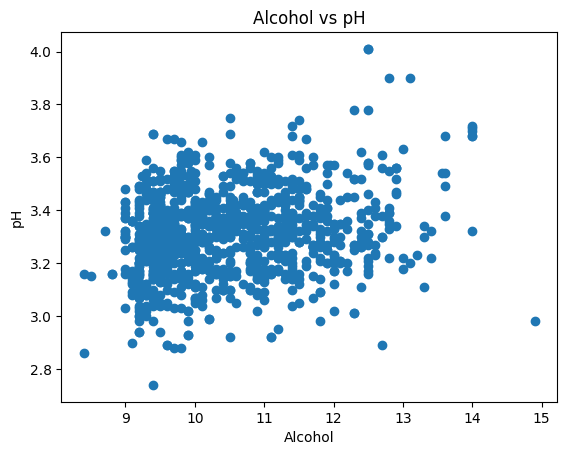

In [ ]:
import matplotlib.pyplot as plt

# 1. Scatter plot: Alcohol vs pH
plt.scatter(dataset["alcohol"], dataset["pH"])
plt.xlabel("Alcohol")
plt.ylabel("pH")
plt.title("Alcohol vs pH")
plt.show()

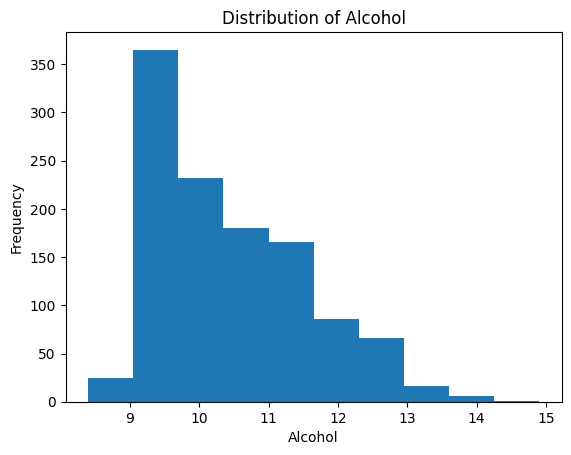

In [ ]:
# 2. Histogram of alcohol
plt.hist(dataset["alcohol"], bins=10)
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.title("Distribution of Alcohol")
plt.show()

<Figure size 800x500 with 0 Axes>

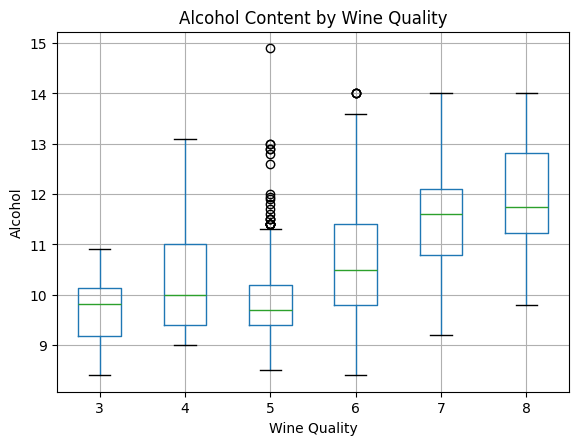

In [ ]:
# 3. Box plot of alcohol grouped by quality
plt.figure(figsize=(8, 5))
dataset.boxplot(column="alcohol", by="quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")
plt.title("Alcohol Content by Wine Quality")
plt.suptitle("")
plt.show()

c) Implement k-NN Classification:
• Remove missing values and prepare features and target.
• Split the data into 80% training and 20% testing sets.
• Standardize the features using StandardScaler.
• Apply k-NN with different values of k and display the accuracy.

• Allow the user to enter k values and display the corresponding accuracy.

In [ ]:
# 1. Remove missing values
dataset=dataset.dropna()

In [ ]:
#Separate features and target
X = dataset.drop(columns=["quality", "Id"])
y = dataset["quality"]

In [ ]:
# 2. Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

In [ ]:
NV# 3. Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 4. Apply k-NN with different values of k
print("\nAccuracy for Different k Values:")
k_values = [1, 3, 5, 7, 9, 11]
for k in k_values:
  # Create k-NN classifier
  knn = KNeighborsClassifier(n_neighbors=k)
# Train the model
knn.fit(X_train, y_train)
# Predict test data
y_pred = knn.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("k =", k, "Accuracy =", accuracy)


Accuracy for Different k Values:
k = 11 Accuracy = 0.62882096069869


In [ ]:
k = int(input("\nEnter the value of k: "))
# Create and train
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
# Predict
y_pred = knn.predict(X_test)
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy for k =", k, ":", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")


Enter the value of k: 3
Accuracy for k = 3 : 0.6069868995633187
Accuracy Percentage: 60.698689956331876 %
